In [1]:
# Banking Intent Classification with DistilBERT
# Objective: classify customer support queries into banking intent categories so incoming requests can be routed more efficiently.


## Project Overview

This notebook presents a multiclass intent-classification workflow for banking support queries.
The goal is to route incoming requests into the right intent category using a transformer-based
NLP model. The pipeline covers data preparation, exploratory analysis, tokenization, DistilBERT
fine-tuning, evaluation, and a lightweight interactive demo.


In [2]:
# --- Project Overview ---
print("\n" + "="*40)
print("Project Overview")
print("="*40)
print("""
Domain: Financial Services Support
Problem Type: Multiclass Intent Classification
Dataset: Banking77 (10-intent prototype subset)

Why this problem matters:
Banks receive large volumes of short, high-variability customer messages such as card issues,
cash withdrawal problems, transfer failures, and account access questions. Manual triage can be
slow and inconsistent, especially when intent boundaries are subtle.

Project goal:
Build a transformer-based model that classifies incoming banking queries into the correct intent
category so they can be routed more consistently to the right support workflow.

Practical value:
A system like this can support faster first-line triage, reduce manual sorting effort, and improve
queue assignment consistency. In real operations, these gains depend on deployment design and human
review workflows, so this notebook treats the project as a decision-support prototype rather than a
production system.

Why a transformer model:
Banking queries are often short but context-sensitive. Transformer models can capture wording and
context relationships more effectively than simpler sequence approaches in many text classification settings.
""")


Project Overview

Domain: Financial Services Support
Problem Type: Multiclass Intent Classification
Dataset: Banking77 (10-intent prototype subset)

Why this problem matters:
Banks receive large volumes of short, high-variability customer messages such as card issues,
cash withdrawal problems, transfer failures, and account access questions. Manual triage can be
slow and inconsistent, especially when intent boundaries are subtle.

Project goal:
Build a transformer-based model that classifies incoming banking queries into the correct intent
category so they can be routed more consistently to the right support workflow.

Practical value:
A system like this can support faster first-line triage, reduce manual sorting effort, and improve
queue assignment consistency. In real operations, these gains depend on deployment design and human
review workflows, so this notebook treats the project as a decision-support prototype rather than a
production system.

Why a transformer model:
Banking que

## Data Loading and Preprocessing

In [3]:
# --- Data Loading and Preprocessing ---

import random
import numpy as np
import pandas as pd
import datasets
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from datasets import Dataset

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("\n" + "="*40)
print("Data Loading and Preprocessing")
print("="*40)

# 1. Load the Banking77 dataset (with a fallback)
try:
    banking_raw = datasets.load_dataset(
        "PolyAI/banking77",
        split="train",
        trust_remote_code=True
    )
    print("Loaded dataset: PolyAI/banking77")
except Exception as e:
    print("PolyAI/banking77 failed, trying banking77. Error:", e)
    banking_raw = datasets.load_dataset(
        "banking77",
        split="train",
        trust_remote_code=True
    )
    print("Loaded dataset: banking77")

# Convert to pandas DataFrame
df = pd.DataFrame(banking_raw)

print(f"Total examples in full dataset: {len(df)}")

# 2. Select Top 10 most frequent intents
label_counts = df["label"].value_counts()
top_10_intents = label_counts.index[:10].tolist()

print("\nTop 10 intent ids:", top_10_intents)

# Filter to top 10 intents only
df_subset = df[df["label"].isin(top_10_intents)].copy()

# 3. Remap original label ids to 0..9 for the classifier head
label_map = {old_label: new_label for new_label, old_label in enumerate(top_10_intents)}
df_subset["label"] = df_subset["label"].map(label_map)

print("\nLabel distribution (after remapping to 0..9):")
print(df_subset["label"].value_counts().sort_index())

# 4. Train/validation split
train_df, val_df = train_test_split(
    df_subset,
    test_size=0.2,
    random_state=SEED,
    stratify=df_subset["label"]
)

print(f"\nTrain size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")

# 5. Convert back to Hugging Face Dataset objects
train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
val_dataset   = Dataset.from_pandas(val_df.reset_index(drop=True))

print("\ntrain_dataset example:")
print(train_dataset[0])


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'PolyAI/banking77' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'PolyAI/banking77' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.



Data Loading and Preprocessing


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

banking77.py: 0.00B [00:00, ?B/s]

...

data/train-00000-of-00001.parquet:   0%|          | 0.00/298k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/93.9k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10003 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3080 [00:00<?, ? examples/s]

Loaded dataset: banking77
Total examples in full dataset: 10003

Top 10 intent ids: [15, 28, 6, 75, 19, 63, 26, 64, 5, 66]

Label distribution (after remapping to 0..9):
label
0    187
1    182
2    181
3    180
4    177
5    175
6    173
7    172
8    171
9    171
Name: count, dtype: int64

Train size: 1415
Validation size: 354

train_dataset example:
{'text': 'There is a direct debit set up that was not authorized by me.', 'label': 1}


In [4]:
# EDA

# Convert HF dataset to pandas
df_full = pd.DataFrame(banking_raw)

print("Full dataset shape:", df_full.shape)

print("\ndf_full.head():")
display(df_full.head())

print("\nDataFrame info:")
df_full.info()


Full dataset shape: (10003, 2)

df_full.head():


,text,label
0,I am still waiting on my card?,11
1,What can I do if my card still hasn't arrived ...,11
2,I have been waiting over a week. Is the card s...,11
3,Can I track my card while it is in the process...,11
4,"How do I know if I will get my card, or if it ...",11



DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10003 entries, 0 to 10002
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    10003 non-null  object
 1   label   10003 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 156.4+ KB


In [5]:
# DATA QUALITY CHECKS ---

print("\nMissing values per column:")
print(df_full.isna().sum())

# Check for duplicate (text, label) pairs
dup_mask = df_full.duplicated(subset=["text", "label"], keep=False)
num_dups = dup_mask.sum()
print(f"\nNumber of duplicate (text, label) rows: {num_dups}")

if num_dups > 0:
    print("\nExample duplicate rows:")
    display(df_full.loc[dup_mask].head())



Missing values per column:
text     0
label    0
dtype: int64

Number of duplicate (text, label) rows: 0



Number of unique intents: 77


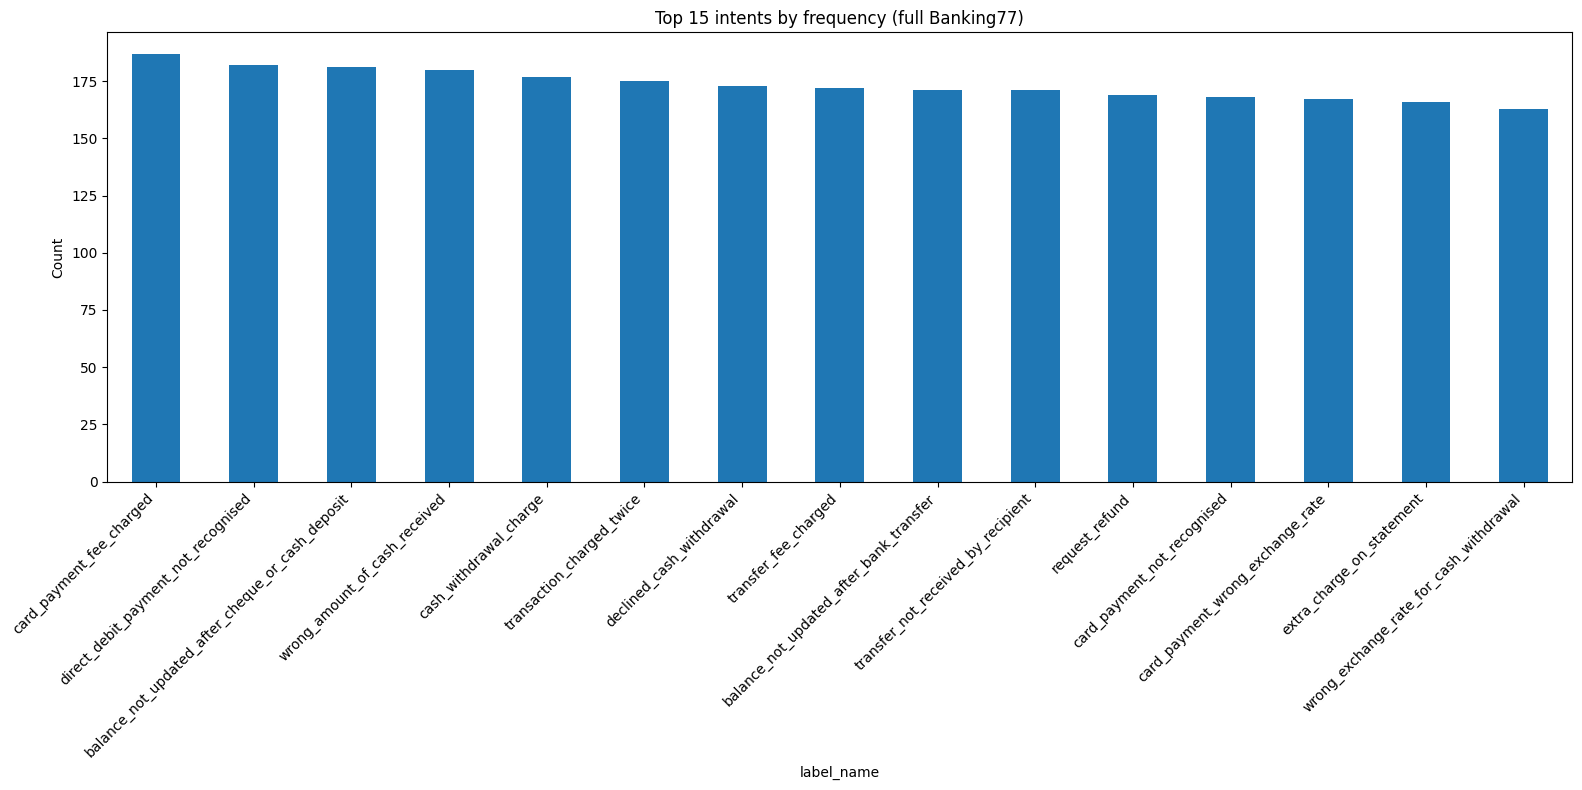


Top 10 intents by frequency:
label_name
card_payment_fee_charged                            187
direct_debit_payment_not_recognised                 182
balance_not_updated_after_cheque_or_cash_deposit    181
wrong_amount_of_cash_received                       180
cash_withdrawal_charge                              177
transaction_charged_twice                           175
declined_cash_withdrawal                            173
transfer_fee_charged                                172
balance_not_updated_after_bank_transfer             171
transfer_not_received_by_recipient                  171
Name: count, dtype: int64

Text length summary (characters):
count    10003.000000
mean        59.473758
std         40.867901
min         13.000000
25%         36.000000
50%         47.000000
75%         64.000000
max        433.000000
Name: char_len, dtype: float64

Text length summary (words):
count    10003.000000
mean        11.949415
std          7.891577
min          2.000000
25%          

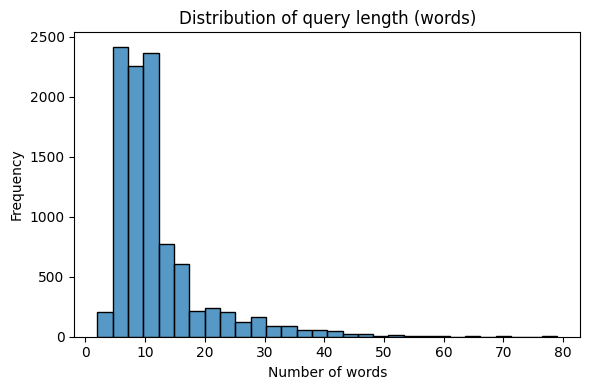

In [6]:

# Map label ids
all_label_names = banking_raw.features["label"].names
df_full["label_name"] = df_full["label"].apply(lambda x: all_label_names[x])

print("\nNumber of unique intents:", df_full["label_name"].nunique())

# Label distribution (all 77, show top 15)
label_counts = df_full["label_name"].value_counts()

plt.figure(figsize=(16, 8))
label_counts.head(15).plot(kind="bar")
plt.title("Top 15 intents by frequency (full Banking77)")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("\nTop 10 intents by frequency:")
print(label_counts.head(10))

# Text length statistics
df_full["char_len"] = df_full["text"].str.len()
df_full["word_len"] = df_full["text"].str.split().apply(len)

print("\nText length summary (characters):")
print(df_full["char_len"].describe())

print("\nText length summary (words):")
print(df_full["word_len"].describe())

plt.figure(figsize=(6, 4))
sns.histplot(df_full["word_len"], bins=30, kde=False)
plt.title("Distribution of query length (words)")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


## Tokenization and Model Setup

In [7]:
# --- Tokenization and Model Setup ---

from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding

print("\n" + "="*40)
print("Tokenization and Model Setup")
print("="*40)

# 1. Load tokenizer
model_checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

# 2. Tokenization function
def preprocess_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding=True,
        max_length=64,  # Banking77 queries are short; 64 is sufficient
    )

# 3. Apply tokenization to train/val datasets
tokenized_train = train_dataset.map(preprocess_function, batched=True)
tokenized_val   = val_dataset.map(preprocess_function, batched=True)

# 4. Data collator for dynamic padding in batches
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# 5. Load DistilBERT classification head with correct number of labels
num_labels = len(set(train_dataset["label"]))
print(f"\nNumber of labels: {num_labels}")

model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=num_labels
)

# 6. Quick sanity check
sample_batch = tokenized_train[0]
print("\nDecoded sample text from tokenized_train[0]:")
print(tokenizer.decode(sample_batch["input_ids"]))
print("Label:", sample_batch["label"])



Tokenization and Model Setup


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...


Number of labels: 10


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Decoded sample text from tokenized_train[0]:
[CLS] there is a direct debit set up that was not authorized by me. [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]
Label: 1



Model Training with Hugging Face Trainer

Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,2.184924,1.330627,0.836158,0.831056
2,1.038371,0.688306,0.918079,0.917131
3,0.597366,0.543610,0.926554,0.925992


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



Final evaluation metrics on validation set:


eval_loss: 0.5436
eval_accuracy: 0.9266
eval_f1: 0.9260
eval_runtime: 0.6288
eval_samples_per_second: 562.9670
eval_steps_per_second: 36.5770
epoch: 3.0000


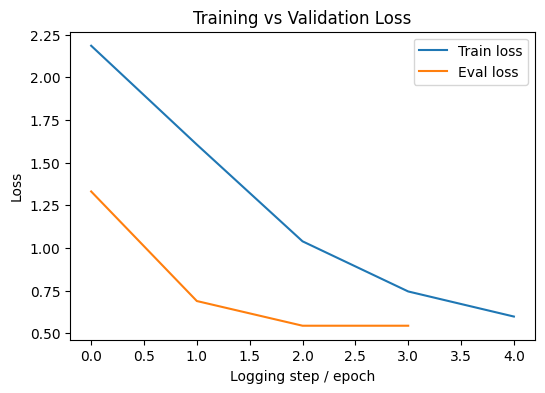

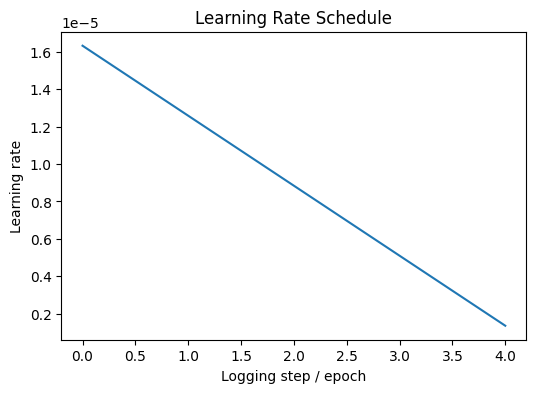

In [8]:
# --- Model Training: DistilBERT Fine-Tuning ---

import numpy as np
from sklearn.metrics import accuracy_score, f1_score
from transformers import TrainingArguments, Trainer
import matplotlib.pyplot as plt

print("\n" + "="*40)
print("Model Training with Hugging Face Trainer")
print("="*40)

# 1. Metrics function: Accuracy + Weighted F1
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    f1  = f1_score(labels, preds, average="weighted")
    return {"accuracy": acc, "f1": f1}

# 2. TrainingArguments
training_args = TrainingArguments(
    output_dir="./banking_results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_steps=50,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# 4. Train the model
print("\nStarting training...")
train_result = trainer.train()

# 5. Final evaluation on validation split
print("\nFinal evaluation metrics on validation set:")
eval_metrics = trainer.evaluate()
for k, v in eval_metrics.items():
    if isinstance(v, (int, float, np.floating)):
        print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: {v}")

# 6. Plot loss curves and learning rate schedule (for convergence & LR tracking)
log_history = trainer.state.log_history

train_loss = [entry["loss"] for entry in log_history if "loss" in entry]
eval_loss  = [entry["eval_loss"] for entry in log_history if "eval_loss" in entry]
lrs        = [entry["learning_rate"] for entry in log_history if "learning_rate" in entry]

if train_loss:
    plt.figure(figsize=(6, 4))
    plt.plot(train_loss, label="Train loss")
    if eval_loss:
        plt.plot(eval_loss, label="Eval loss")
    plt.xlabel("Logging step / epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.show()

if lrs:
    plt.figure(figsize=(6, 4))
    plt.plot(lrs)
    plt.xlabel("Logging step / epoch")
    plt.ylabel("Learning rate")
    plt.title("Learning Rate Schedule")
    plt.show()


## Prediction Analysis and Error Review


Prediction Analysis and Error Review

Class names (top 10 intents):
0: card_payment_fee_charged
1: direct_debit_payment_not_recognised
2: balance_not_updated_after_cheque_or_cash_deposit
3: wrong_amount_of_cash_received
4: cash_withdrawal_charge
5: transaction_charged_twice
6: declined_cash_withdrawal
7: transfer_fee_charged
8: balance_not_updated_after_bank_transfer
9: transfer_not_received_by_recipient


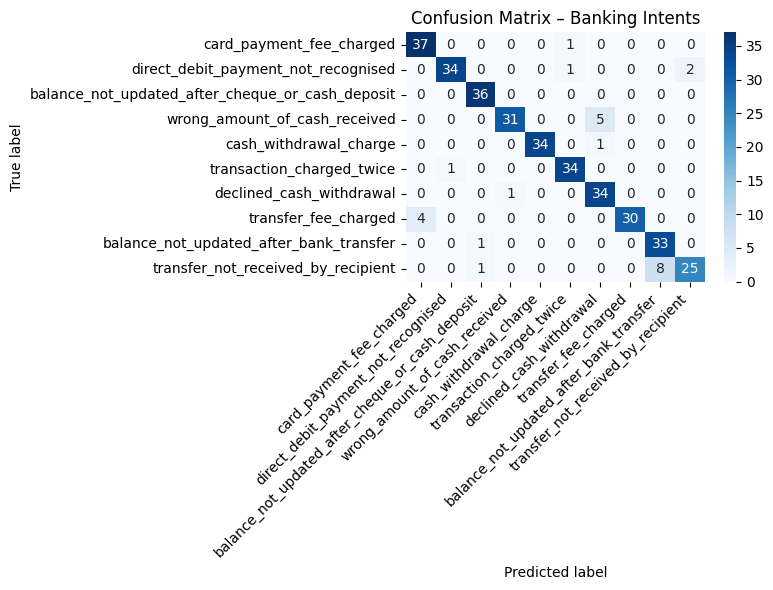


Classification Report:
                                                  precision    recall  f1-score   support

                        card_payment_fee_charged     0.9024    0.9737    0.9367        38
             direct_debit_payment_not_recognised     0.9714    0.9189    0.9444        37
balance_not_updated_after_cheque_or_cash_deposit     0.9474    1.0000    0.9730        36
                   wrong_amount_of_cash_received     0.9688    0.8611    0.9118        36
                          cash_withdrawal_charge     1.0000    0.9714    0.9855        35
                       transaction_charged_twice     0.9444    0.9714    0.9577        35
                        declined_cash_withdrawal     0.8500    0.9714    0.9067        35
                            transfer_fee_charged     1.0000    0.8824    0.9375        34
         balance_not_updated_after_bank_transfer     0.8049    0.9706    0.8800        34
              transfer_not_received_by_recipient     0.9259    0.7353    0.

In [9]:
# --- Prediction Analysis and Error Review ---

import numpy as np
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

print("\n" + "=" * 40)
print("Prediction Analysis and Error Review")
print("=" * 40)

# -------------------------------------------------------------------
# 1) Label names for top-10 intents
# -------------------------------------------------------------------
original_label_names = banking_raw.features["label"].names
subset_label_names = [original_label_names[i] for i in top_10_intents]

id2label = {new_id: name for new_id, name in enumerate(subset_label_names)}
label2id = {v: k for k, v in id2label.items()}
class_names = [id2label[i] for i in range(len(id2label))]

print("\nClass names (top 10 intents):")
for i, name in enumerate(class_names):
    print(f"{i}: {name}")

# -------------------------------------------------------------------
# 2) Predictions on validation set + confusion matrix
# -------------------------------------------------------------------
pred_output = trainer.predict(tokenized_val)

logits = pred_output.predictions
labels = pred_output.label_ids
preds = np.argmax(logits, axis=-1)

cm = confusion_matrix(labels, preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix – Banking Intents")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(labels, preds, target_names=class_names, digits=4))

# -------------------------------------------------------------------
# 3) Example correct and misclassified predictions
# -------------------------------------------------------------------
val_texts = val_dataset["text"]

examples = []

for i, (text, true_id, pred_id) in enumerate(zip(val_texts, labels, preds)):
    examples.append(
        {
            "idx": i,
            "text": text,
            "true_label_id": int(true_id),
            "pred_label_id": int(pred_id),
            "true_label": id2label[int(true_id)],
            "pred_label": id2label[int(pred_id)],
            "correct": bool(true_id == pred_id),
        }
    )

correct_examples = [ex for ex in examples if ex["correct"]]
error_examples = [ex for ex in examples if not ex["correct"]]

print("\n\nExample correct predictions:")
for ex in correct_examples[:5]:
    print("-" * 80)
    print(f"Text: {ex['text']}")
    print(f"True label: {ex['true_label']}")
    print(f"Predicted label: {ex['pred_label']}")

print("\n\nExample misclassified predictions:")
for ex in error_examples[:5]:
    print("-" * 80)
    print(f"Text: {ex['text']}")
    print(f"True label: {ex['true_label']}")
    print(f"Predicted label: {ex['pred_label']}")

# -------------------------------------------------------------------
# 4) Prediction confidence review for a single query
# -------------------------------------------------------------------
device = model.device

def predict_intent(input_text, top_k=3):
    """
    Runs the fine-tuned model on a sample customer query and prints
    the top predicted intents with confidence scores.
    """
    model.eval()

    encoded = tokenizer(
        input_text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=64,
    )

    encoded = {k: v.to(device) for k, v in encoded.items()}

    with torch.no_grad():
        outputs = model(**encoded)

    probabilities = torch.softmax(outputs.logits, dim=-1)[0]
    top_probs, top_ids = torch.topk(probabilities, k=top_k)

    print(f"\nQuery: {input_text}")
    print("\nTop predicted intents:")

    for score, label_id in zip(top_probs, top_ids):
        label_id = int(label_id)
        print(f"- {id2label[label_id]}: {float(score):.4f}")

# Run prediction confidence review on a sample query
test_sentence = "My card was swallowed by the ATM and I need help."

print("\n\nPrediction confidence review for example query:")
predict_intent(test_sentence)

## Operational Relevance

A model like this can support first-line triage for customer support operations by helping
route incoming requests to the correct queue faster. In practice, this kind of workflow can
improve consistency, reduce manual sorting effort, and make downstream review more efficient.


In [10]:
# --- Operational Relevance ---

import pandas as pd
import numpy as np

print("\n" + "="*40)
print("Operational Relevance")
print("="*40)

# 1) Re-evaluate on validation set to get final metrics
eval_metrics = trainer.evaluate(tokenized_val)

# Handle different key names depending on transformers version
acc = eval_metrics.get("eval_accuracy", eval_metrics.get("accuracy", None))
f1  = eval_metrics.get("eval_f1",      eval_metrics.get("f1", None))

print("\nRaw eval metrics from Trainer:")
for k, v in eval_metrics.items():
    if isinstance(v, (int, float, np.floating)):
        print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: {v}")

# 2) Build a simple Technical → Operational Relevance table
metrics_rows = [
    {
        "Metric": "Accuracy",
        "Value": f"{acc:.3f}" if acc is not None else "N/A",
        "Business Meaning": "Share of customer queries classified into the correct intent category in this evaluation setup."
    },
    {
        "Metric": "Weighted F1-score",
        "Value": f"{f1:.3f}" if f1 is not None else "N/A",
        "Business Meaning": "Balances precision and recall across intents; useful when overall accuracy alone hides uneven class performance."
    },
    {
        "Metric": "Coverage Scope",
        "Value": "10 intents",
        "Business Meaning": "This notebook is a scoped prototype built on a subset of Banking77 rather than a full production routing taxonomy."
    },
    {
        "Metric": "Operational Triage Effort",
        "Value": "Potential reduction",
        "Business Meaning": "Better intent classification may reduce manual sorting effort before a case reaches the right team."
    },
    {
        "Metric": "Routing Consistency",
        "Value": "Potential improvement",
        "Business Meaning": "More consistent intent assignment can help downstream teams start with better context, depending on workflow design."
    },
]

impact_df = pd.DataFrame(metrics_rows)
print("\nTechnical → Operational Relevance Table:")
display(impact_df)

# 3) Short textual summary for workflow impact
print("\nWorkflow Impact Summary:")
print("-" * 80)
print(
    "• A transformer-based intent classifier can serve as a first-line triage aid by\n"
    "  assigning incoming queries to an initial support category before human review.\n"
    "• In a real support workflow, this could reduce manual routing effort and make\n"
    "  queue assignment more consistent, especially for repetitive high-volume intents.\n"
    "• Class-level performance matters because uneven results across intents can create\n"
    "  downstream review burden even when overall accuracy looks strong."
)

# 4) Failure modes & limitations
print("\nFailure Modes & Limitations:")
print("-" * 80)
print(
    "• Short, extremely vague queries (e.g., 'problem with account') can still be\n"
    "  misclassified because there is not enough signal in the text.\n"
    "• Slang, heavy typos, or unseen product names may confuse the model and push it\n"
    "  toward a generic intent.\n"
    "• The current model was trained on only the top 10 intents of Banking77; in a real\n"
    "  production setting, many more intents and languages would need to be supported.\n"
    "• Model performance depends on the training data distribution, so new products or\n"
    "  policy changes would require monitoring and periodic retraining."
)



Operational Relevance



Raw eval metrics from Trainer:
eval_loss: 0.5436
eval_accuracy: 0.9266
eval_f1: 0.9260
eval_runtime: 0.6288
eval_samples_per_second: 563.0060
eval_steps_per_second: 36.5790
epoch: 3.0000

Technical → Operational Relevance Table:


,Metric,Value,Business Meaning
0,Accuracy,0.927,Share of customer queries classified into the ...
1,Weighted F1-score,0.926,Balances precision and recall across intents; ...
2,Coverage Scope,10 intents,This notebook is a scoped prototype built on a...
3,Operational Triage Effort,Potential reduction,Better intent classification may reduce manual...
4,Routing Consistency,Potential improvement,More consistent intent assignment can help dow...



Workflow Impact Summary:
--------------------------------------------------------------------------------
• A transformer-based intent classifier can serve as a first-line triage aid by
  assigning incoming queries to an initial support category before human review.
• In a real support workflow, this could reduce manual routing effort and make
  queue assignment more consistent, especially for repetitive high-volume intents.
• Class-level performance matters because uneven results across intents can create
  downstream review burden even when overall accuracy looks strong.

Failure Modes & Limitations:
--------------------------------------------------------------------------------
• Short, extremely vague queries (e.g., 'problem with account') can still be
  misclassified because there is not enough signal in the text.
• Slang, heavy typos, or unseen product names may confuse the model and push it
  toward a generic intent.
• The current model was trained on only the top 10 intents o

## Interactive Demo

In [11]:
# --- Interactive Intent Demo with Gradio ---

print("\n" + "="*40)
print("Interactive Intent Classification Demo")
print("="*40)

import torch
import torch.nn.functional as F

# Install gradio if needed
try:
    import gradio as gr
except ImportError:
    !pip install gradio -q
    import gradio as gr

model.eval()
device = model.device

# Rebuild id2label / class_names if needed (in case of kernel restart)
try:
    id2label
    class_names
except NameError:
    original_label_names = banking_raw.features["label"].names
    subset_label_names = [original_label_names[i] for i in top_10_intents]
    id2label = {new_id: name for new_id, name in enumerate(subset_label_names)}
    class_names = [id2label[i] for i in range(len(id2label))]

def classify_intent_probs(user_text: str):
    """
    Run the fine-tuned model and return a dict of {label: probability}.
    Gradio's Label component will render this as a bar chart.
    """
    text = user_text.strip()
    if not text:
        # Returning empty dict will show nothing
        return {}

    encoded = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=64,
    )
    encoded = {k: v.to(device) for k, v in encoded.items()}

    with torch.no_grad():
        outputs = model(**encoded)
    logits = outputs.logits
    probs = F.softmax(logits, dim=-1)[0].cpu().numpy()

    # Build dict {label: prob} for all classes (Label will show top N)
    prob_dict = {id2label[i]: float(probs[i]) for i in range(len(probs))}
    return prob_dict

demo = gr.Interface(
    fn=classify_intent_probs,
    inputs=gr.Textbox(
        lines=2,
        label="user_query",
        placeholder="Transaction fee was charged twice."
    ),
    outputs=gr.Label(
        num_top_classes=3,    # shows top-3 with bars, like your second screenshot
        label="output"
    ),
    title="Banking Intent AI 🏦",
    description="Ask a question about your bank account to see how BERT classifies it.",
    examples=[
        ["Transaction fee was charged twice."],
        ["Why is there an extra fee on my withdrawal?"],
        ["My transfer to France hasn't arrived yet."],
        ["The ATM took my card and didn't give me cash."],
        ["The cash I deposited yesterday isn’t in my balance."],
        ["Why was I charged a fee for this card payment?"],
    ],
)

print("Run demo.launch() in a separate cell to open the UI.")
demo.launch()



Interactive Intent Classification Demo
Run demo.launch() in a separate cell to open the UI.
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ff44a1ef5cbf95423b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
